In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [ ]:
df1 = pd.read_csv('../data/CRMLSSold202505.csv')
df2 = pd.read_csv('../data/CRMLSSold202506.csv')
df3 = pd.read_csv('../data/CRMLSSold202507.csv')
df4 = pd.read_csv('../data/CRMLSSold202508.csv')
df5 = pd.read_csv('../data/CRMLSSold202509.csv')
df6 = pd.read_csv('../data/CRMLSSold202510.csv')
df7 = pd.read_csv('../data/CRMLSSold202511.csv')
df8 = pd.read_csv('../data/CRMLSSold202512.csv')
df9 = pd.read_csv('../data/CRMLSSold202601.csv')
df10 = pd.read_csv('../data/CRMLSSold202602.csv')
df11 = pd.read_csv('../data/CRMLSSold202603.csv')
df12 = pd.read_csv('../data/CRMLSSold202604.csv')
df13 = pd.read_csv('../data/CRMLSSold202605.csv')

df = pd.concat([df1, df2, df3, df4, df5, df6, df7, df8, df9, df10, df11, df12, df13], axis=0, ignore_index=True)
df = df.drop(['ListPrice', 'OriginalListPrice'], axis=1)

# Restricting analysis according to Project Document
df = df[df['PropertyType'] == 'Residential']
df = df[df['PropertySubType'] == 'SingleFamilyResidence']

/var/folders/3l/3v_d6vqj7892stpd98hwf1ym0000gn/T/ipykernel_5796/2931963940.py:2: DtypeWarning: Columns (0: WaterfrontYN) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('../data/CRMLSSold202506.csv')
/var/folders/3l/3v_d6vqj7892stpd98hwf1ym0000gn/T/ipykernel_5796/2931963940.py:9: DtypeWarning: Columns (0: WaterfrontYN, 1: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  df9 = pd.read_csv('../data/CRMLSSold202601.csv')


In [5]:
df['ClosePrice'].hasnans

False

(This dataset contains all properties that have a ClosePrice. Their statuses are closed.)

### Listing & Transaction Information:
- ListingKey
- ListingKeyNumeric
- ListingId
- ListingContractDate
- PurchaseContractDate
- ContractStatusChangeDate
- CloseDate
- DaysOnMarket
- MlsStatus

We want to decide which of these features will be most helpful in predicting ClosePrice in our model.

### ListingKey
ListingKey is the primary key.

### ListingKeyNumeric
ListingKeyNumeric seems to be the same as the primary key.

### ListingId
ListingId is also a type of key, with human-identifiable values.

### ListingContractDate
ListingContractDate is the date of the agreement/contract between the seller and the seller's broker. This is stage 1 of the transaction lifecycle.

In [12]:
df_ListingContractDate = df.copy()
df_ListingContractDate['ListingContractDate'] = pd.to_datetime(df_ListingContractDate['ListingContractDate'])
# Convert datetime to a numeric float
df_ListingContractDate['ListingContractDateNumeric'] = df_ListingContractDate['ListingContractDate'].astype('int64') // 10**9 

# correlation coefficient
df_ListingContractDate['ListingContractDateNumeric'].corr(df_ListingContractDate['ClosePrice'])

np.float64(-0.0010410206445926372)

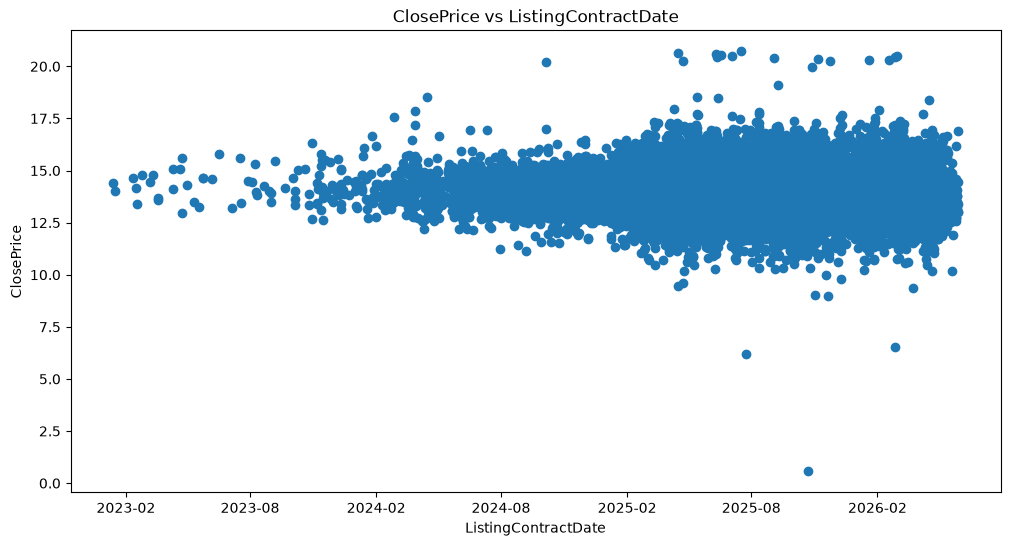

In [22]:
# ignore sparse data before 2023
df_ListingContractDate = df_ListingContractDate[df_ListingContractDate['ListingContractDate'] > pd.to_datetime('2023-01-01')]

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(df_ListingContractDate['ListingContractDate'].sort_values(), np.log(df_ListingContractDate['ClosePrice']))

plt.xlabel('ListingContractDate')
plt.ylabel('ClosePrice')
plt.title('ClosePrice vs ListingContractDate')

# show a tick every 6 months on the x axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

When we apply log to ClosePrice, the data seems fairly evenly spread and consistent over time around a y-value of 12.5-16. The correlation coefficient is very close to 0, so this feature may not be helpful.

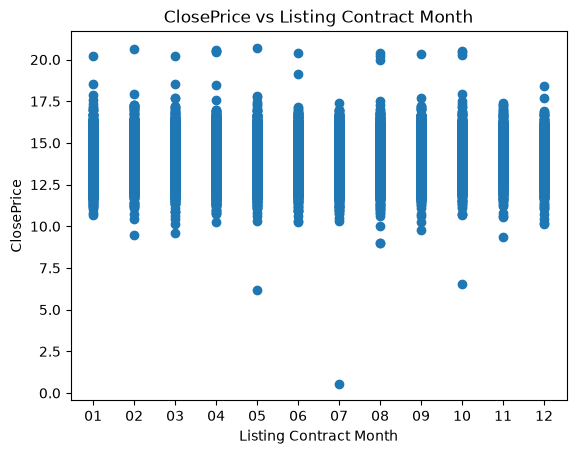

In [18]:
plt.xlabel('Listing Contract Month')
plt.ylabel('ClosePrice')
plt.title('ClosePrice vs Listing Contract Month')

# df sorted by month
df_monthly = df.copy()
df_monthly['ListingContractMonth'] = df_monthly['ListingContractDate'].str[5:7]
plt.scatter(df_monthly['ListingContractMonth'].sort_values(), np.log(df['ClosePrice']));

Grouping by month does not look very helpful either, as there do not seem to be significant seasonal trends.

### PurchaseContractDate
This is the date an offer was accepted by contract and the listing was taken off the market.

In [8]:
# PurchaseContractDate has NaN values --> replace with empty string
df_PurchaseContractDate = df.copy()
df_PurchaseContractDate['PurchaseContractDate'] = df['PurchaseContractDate'].fillna("")

In [9]:
df_PurchaseContractDate['PurchaseContractDate'] = pd.to_datetime(df_PurchaseContractDate['PurchaseContractDate'])
# Convert datetime to a numeric float
df_PurchaseContractDate['PurchaseContractDateNumeric'] = df_PurchaseContractDate['PurchaseContractDate'].astype('int64') // 10**9 

df_PurchaseContractDate['PurchaseContractDateNumeric'].corr(df_PurchaseContractDate['ClosePrice'])

np.float64(0.0004978197249668749)

The correlation coefficient between PurchaseContractDate and ClosePrice is very close to 0, so this feature may not be helpful.

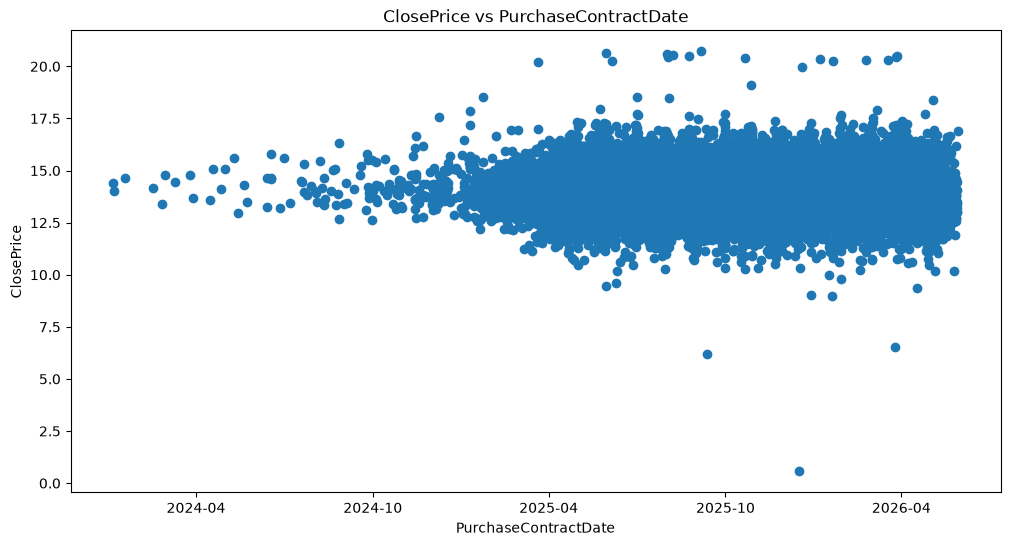

In [11]:
# ignore sparse data before 2024
df_PurchaseContractDate = df_PurchaseContractDate[df_PurchaseContractDate['PurchaseContractDate'] > pd.to_datetime('2024-01-01')]

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(df_PurchaseContractDate['PurchaseContractDate'].sort_values(), np.log(df_PurchaseContractDate['ClosePrice']));

plt.xlabel('PurchaseContractDate')
plt.ylabel('ClosePrice')
plt.title('ClosePrice vs PurchaseContractDate')

# show a tick every 6 months on the x axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

The visualization supports this.

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


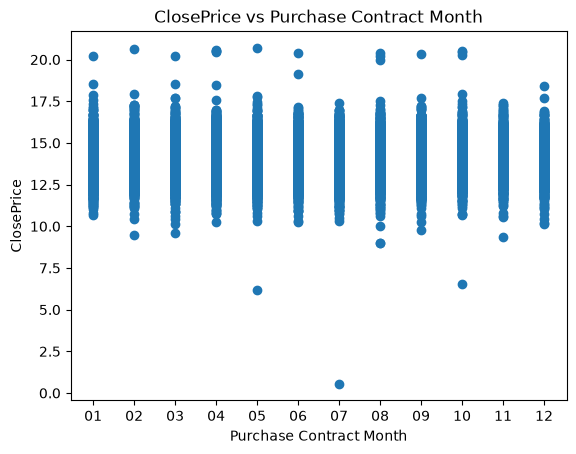

In [12]:
plt.xlabel('Purchase Contract Month')
plt.ylabel('ClosePrice')
plt.title('ClosePrice vs Purchase Contract Month')

# df sorted by month
df_PurchaseContractDate['ListingContractMonth'] = df_PurchaseContractDate['ListingContractDate'].str[5:7]
plt.scatter(df_PurchaseContractDate['ListingContractMonth'].sort_values(), np.log(df_PurchaseContractDate['ClosePrice']));

There do not seem to be significant seasonal trends here.

### ContractStatusChangeDate
This is the date that there was a change to the contract status.

In [19]:
df_ContractStatusChangeDate = df.copy()
df_ContractStatusChangeDate['ContractStatusChangeDate'] = pd.to_datetime(df_ContractStatusChangeDate['ContractStatusChangeDate'])
# Convert datetime to a numeric float
df_ContractStatusChangeDate['ContractStatusChangeDateNumeric'] = df_ContractStatusChangeDate['ContractStatusChangeDate'].astype('int64') // 10**9 

df_ContractStatusChangeDate['ContractStatusChangeDateNumeric'].corr(df_ContractStatusChangeDate['ClosePrice'])

np.float64(0.001854604960936933)

No significant relationship here.

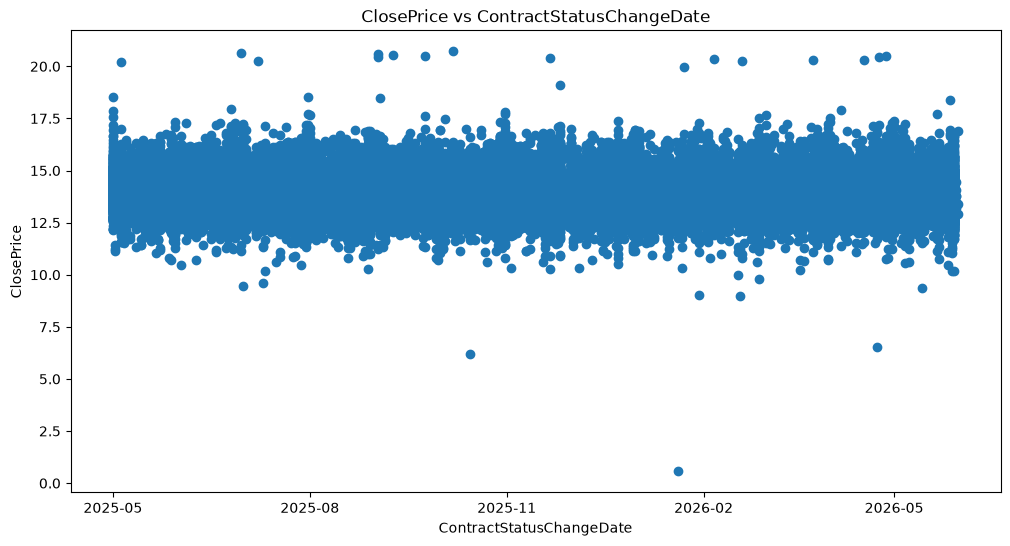

In [24]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(df_ContractStatusChangeDate['ContractStatusChangeDate'].sort_values(), np.log(df_ContractStatusChangeDate['ClosePrice']))

plt.xlabel('ContractStatusChangeDate')
plt.ylabel('ClosePrice')
plt.title('ClosePrice vs ContractStatusChangeDate')

# show a tick every 3 months on the x axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3));

The data is highly consistent, but no trends.

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


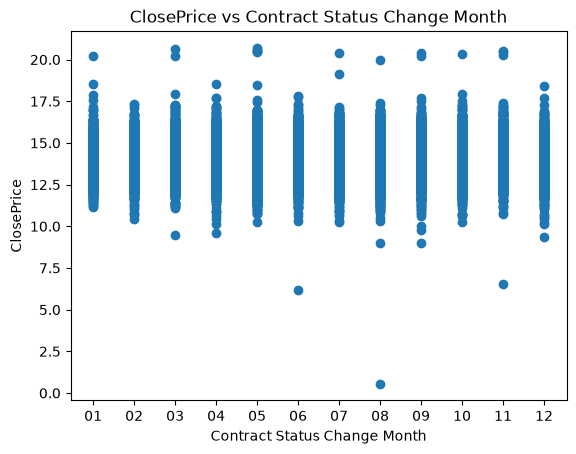

In [19]:
plt.xlabel('Contract Status Change Month')
plt.ylabel('ClosePrice')
plt.title('ClosePrice vs Contract Status Change Month')

# df sorted by month
df_ContractStatusChangeDate['ContractStatusChangeMonth'] = df['ContractStatusChangeDate'].str[5:7]
plt.scatter(df_ContractStatusChangeDate['ContractStatusChangeMonth'].sort_values(), np.log(df_ContractStatusChangeDate['ClosePrice']));

No significant relationship here either.

### CloseDate
The date the purchase agreement/requirement was fulfilled.

In [36]:
df_CloseDate = df.copy()
df_CloseDate['CloseDate'] = pd.to_datetime(df_CloseDate['CloseDate'])
# Convert datetime to a numeric float
df_CloseDate['CloseDateNumeric'] = df_CloseDate['CloseDate'].astype('int64') // 10**9 

df_CloseDate['CloseDateNumeric'].corr(df_CloseDate['ClosePrice'])

np.float64(0.0018543344408505952)

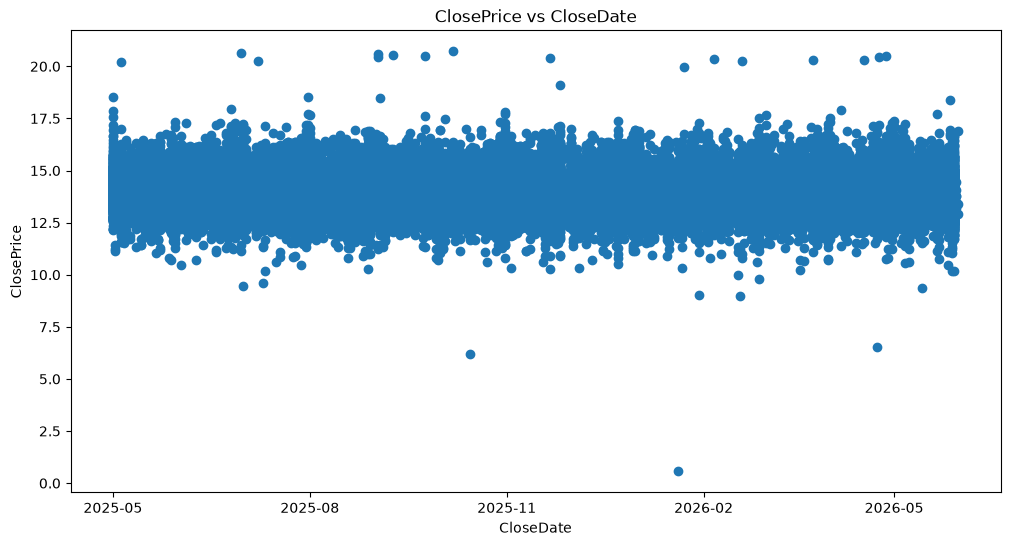

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(df_CloseDate['CloseDate'].sort_values(), np.log(df_CloseDate['ClosePrice']));

plt.xlabel('CloseDate')
plt.ylabel('ClosePrice')
plt.title('ClosePrice vs CloseDate')

# show a tick every 3 months on the x axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


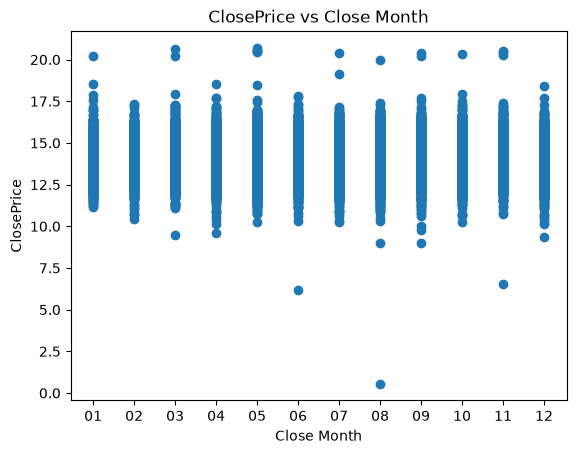

In [28]:
plt.xlabel('Close Month')
plt.ylabel('ClosePrice')
plt.title('ClosePrice vs Close Month')

# df sorted by month
df_CloseDate['CloseDate'] = df['CloseDate'].str[5:7]
plt.scatter(df_CloseDate['CloseDate'].sort_values(), np.log(df_CloseDate['ClosePrice']));

No significant trend.

### DaysOnMarket
The number of days that the listing was on market.

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


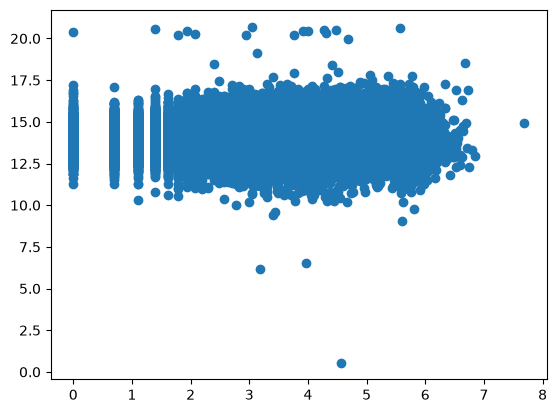

In [34]:
plt.scatter(np.log(df['DaysOnMarket']), np.log(df['ClosePrice']))

### MlsStatus
MlsStatus is 'Closed' for all data entries.

# NEXT:
- Finish days on market. Can this be made into a good feature to use?
- Research the different types of models (other than linear regression). Can ListingContractDate and PurchaseContract Date be used for any of these models?
- Look at the variance of the ListingContractDate and PurchaseContractDate visualizations too. Can that help with our model?